In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

In [4]:
Ts_DF = [0]+[2**i for i in np.arange(7,8)]+[150,200,225,256,300,400,512]+[750]+[1024,1250,1500,2048]
Ts_DF_final = [0,128,256, 512, 750, 1024, 1250, 1500, 2048]
step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/RF_oh_w_time0_2048_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_DF):
        if T not in Ts_DF_final:
            pass
        else:
            irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
            preward = compute_normalized_future_rewards(irewards,100,0.5,normalization=True)
            path, ireward_opt = path_opt(states[k,0], T, 100)
            preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization=True)
            pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
            prewards.append(np.sum(preward).item())
            pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_DF_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_DF_arr.shape)

Ts_PVFM = [1000,5000,10000,20000,40000,80000]
fn = f"../results/PVFM/RF_oh_w_time1000_80000_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_PVFM_arr = data["pregrets"]
print(PREGRETS_PVFM_arr.shape)

fn = f"../results/PVAFM/GBT_pregrets_gamma0.9_oh_w_time0_2048_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_RF_arr = data["pregrets"]
Ts = data['t_list']
Ts = Ts[1:]
# Ts[0] = 1
print(len(Ts))

(10, 9)
(10, 6)
9


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_84345/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_84345/2613591833.py:40: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,100000])


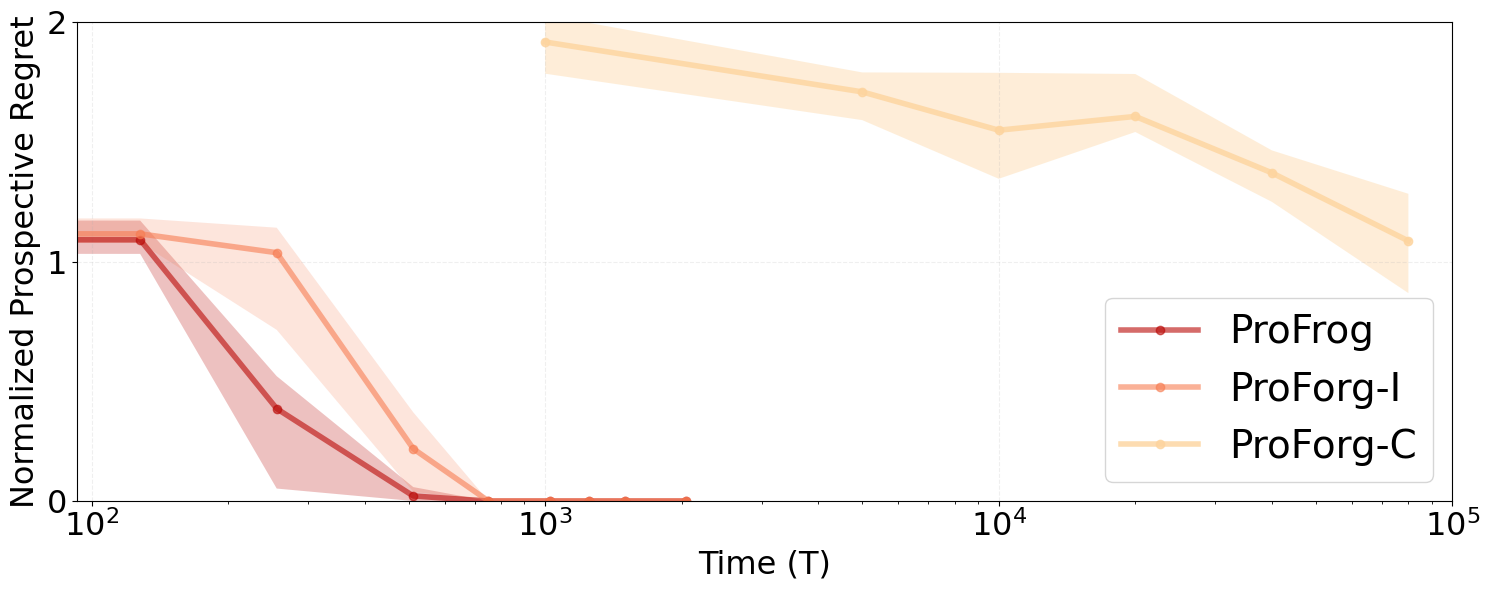

In [ ]:
plt.figure(figsize=(15, 6))
linewidth = 4
fontsize = 28

pavfm_df,pafm_df, pvfm_df, = get_close_colors("OrRd", start = 0.85, delta = -0.3, n = 3) 

colors = {
    "PAFM_oh_RF": pafm_df,
    "PVFM_oh_RF": pvfm_df,
    "PAVFM_RF":pavfm_df,
    }

## Plot DF
median = np.nanmedian(PREGRETS_RF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_RF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_RF_arr, 75, axis=0)
plt.plot(Ts, median,color=colors["PAVFM_RF"], lw = linewidth,alpha = 0.6,label = 'ProFrog',marker='o')
plt.fill_between(Ts, q25, q75, color=colors["PAVFM_RF"], alpha=0.25, edgecolor="none")


median = np.median(PREGRETS_PAFM_DF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 75, axis=0)
plt.plot(Ts, median,color=colors["PAFM_oh_RF"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProForg-I')
plt.fill_between(Ts, q25, q75, color=colors["PAFM_oh_RF"], alpha=0.20, edgecolor="none")


median = np.nanmedian(PREGRETS_PVFM_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PVFM_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PVFM_arr, 75, axis=0)
plt.plot(Ts_PVFM, median,color=colors["PVFM_oh_RF"], lw = linewidth,marker='o',alpha = 0.8,label = 'ProForg-C')
plt.fill_between(Ts_PVFM, q25, q75, color=colors["PVFM_oh_RF"], alpha=0.40, edgecolor="none")

plt.xlabel("Time (T)",fontsize = fontsize-5)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize-5)
plt.xscale('log')


plt.xticks(fontsize=fontsize-5)
plt.xlim([0,100000])
plt.ylim([0,2])
plt.yticks([0,1,2],fontsize = fontsize-5)
plt.legend(fontsize = fontsize)
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()

plt.savefig("ProForg_Instantaneous_vs_Continuous.png")
